In [5]:
!pip install vk_api networkx pandas matplotlib

In [189]:
import vk_api

TOKEN = 'vk1.a.7a_phvgxIU3zpgRFUH1TSLQwMQ_1XFfiBupoBSRP1Q28dnx1aRSh3Y40VW7L114Lm_RtaOgyk_ZtjIzY337nxYK3KzvKy2Ueq3yitP74v2gNXrQeTA-BrQ800bRul8oqI_lj8wB6_rUzdfAKga6Lx0wRLL2cPZyC4EI6xrpdohzyWLTMOG9dV5N2hgHyvmugZCNJqkKquRSdq3B22Cco0w'

# Подключаемся к VK
vk_session = vk_api.VkApi(token=TOKEN)
vk = vk_session.get_api()

# Проверка токена
try:
    my_info = vk.users.get()
    print("Токен работает!")
    print(f"Вы вошли как: {my_info[0]['first_name']} {my_info[0]['last_name']}")
    print(f"Ваш ID: {my_info[0]['id']}")
except Exception as e:
    print(f"Ошибка: {e}")

Токен работает!
Вы вошли как: Анна Лиса
Ваш ID: 882021567


In [191]:
import pandas as pd

# Читаем Excel со ссылками
df = pd.read_excel('members.xlsx', header=None)
links = df[0].tolist()
names = df[1].tolist() if df.shape[1] > 1 else [''] * len(links)

# Извлекаем короткие имена из ссылок
short_names = []
for link in links:
    parts = str(link).strip().rstrip('/').split('/')
    short_names.append(parts[-1])

print("Короткие имена:", short_names)
print("\nИмена:", names)
print("\nСловарь:", dict(zip(short_names, names)))

Короткие имена: ['metonimiaa', 'kotletosss', 'id422397933', 'antonlevn', 's.abramov2', 'dimabazlov', 'gs1ayer', 'daioru', 'freezefinn', 'fed_serega', 'rskator', 'rudnev911', 'fulliener', 'id830638754', '1nkarat', 'id1098513955', 'ogponcha', 'andrew.kirillov', 'bignigga', 'y.doyneko', 'saulinivan', 'dimitr101', 'ku_ku_riz', 'medvediano', 'flashik12', '0pupok00', 'ryosuk3', 'id139159408', 'dedvnutree']

Имена: ['Артем Кузьмин', 'Мария Александрова', 'Андрей Клейменов', 'Ле Хиеп-Хый', 'Сергей Абрамов', 'Дмитрий Базлов', 'Александр Васильев', 'Кирилл Кучеренко', 'Кирилл Дренин', 'Сергей Федькин', 'Руслан Аллабергенов', 'Илья Руднев', 'Ruslän Dächev', 'Клим Волохов', 'Никита Марков', 'Дмитрий Ядовитый', 'Илья Бурмистров', 'Андрей Кириллов', 'Игорь Сусаров', 'Юлия Дойнеко', 'Иван Саулин', 'Дмитрий Полуэктов', 'Денис Давыдов', 'Илья Медведев', 'Александр Ершов', 'Лия Мартынова', 'Владимир Романенко', 'Даниил Нисанов', 'Александр Голоктионов']

Словарь: {'metonimiaa': 'Артем Кузьмин', 'kotleto

In [193]:
# Преобразуем короткие имена в цифровые ID
try:
    users_info = vk.users.get(user_ids=short_names)
    ids = [user['id'] for user in users_info]
    print("Найдены ID:", ids)
except Exception as e:
    print(f"Ошибка: {e}")

Найдены ID: [214576903, 147436715, 422397933, 708207289, 354792455, 437474057, 193511426, 229017385, 133821410, 172152768, 677045683, 278508214, 392942223, 830638754, 241970575, 1098513955, 301455650, 357111839, 447383697, 365680993, 223966628, 299547783, 288851914, 465105120, 198182178, 473310225, 424935969, 139159408, 236434667]


In [195]:
import time

# Словарь, где ключ — ID участника, значение — список его друзей
friends_dict = {}

for user_id in ids:
    try:
        # Запрашиваем друзей
        friends = vk.friends.get(user_id=user_id)
        friend_ids = friends['items']
        friends_dict[user_id] = friend_ids
        print(f"ID {user_id}: {len(friend_ids)} друзей")
        time.sleep(0.34)  # Задержка, чтобы не превысить лимит запросов VK
    except Exception as e:
        print(f"Ошибка для ID {user_id}: {e}")
        friends_dict[user_id] = []
        
id_to_name = dict(zip(ids, names))

print("\nСбор завершен")

ID 214576903: 126 друзей
ID 147436715: 112 друзей
ID 422397933: 5000 друзей
ID 708207289: 111 друзей
ID 354792455: 87 друзей
ID 437474057: 40 друзей
Ошибка для ID 193511426: [30] This profile is private
ID 229017385: 20 друзей
ID 133821410: 127 друзей
ID 172152768: 62 друзей
ID 677045683: 108 друзей
ID 278508214: 104 друзей
ID 392942223: 211 друзей
ID 830638754: 18 друзей
ID 241970575: 87 друзей
ID 1098513955: 1 друзей
ID 301455650: 60 друзей
ID 357111839: 256 друзей
ID 447383697: 104 друзей
ID 365680993: 289 друзей
ID 223966628: 153 друзей
ID 299547783: 272 друзей
ID 288851914: 105 друзей
ID 465105120: 181 друзей
Ошибка для ID 198182178: [30] This profile is private
ID 473310225: 177 друзей
ID 424935969: 30 друзей
ID 139159408: 275 друзей
Ошибка для ID 236434667: [30] This profile is private

Сбор завершен


In [197]:
# Создаем список для связей
edges = []

for user_id, friend_ids in friends_dict.items():
    for friend_id in friend_ids:
        # Проверяем, есть ли этот друг в списке участников
        if friend_id in ids:
            # Записываем связь
            if user_id < friend_id:
                edges.append((user_id, friend_id))

print(f"Найдено {len(edges)} связей между участниками.")
print("Связи:", edges[:14])

Найдено 14 связей между участниками.
Связи: [(422397933, 437474057), (354792455, 357111839), (229017385, 422397933), (172152768, 301455650), (278508214, 354792455), (278508214, 357111839), (241970575, 278508214), (241970575, 354792455), (357111839, 422397933), (223966628, 299547783), (223966628, 365680993), (299547783, 365680993), (299547783, 422397933), (465105120, 473310225)]


In [199]:
import networkx as nx

# Создаем таблицу связей
edges_df = pd.DataFrame(edges, columns=['Кто', 'С кем'])
print("Таблица связей создана")

# Строим граф
G = nx.from_pandas_edgelist(edges_df, 'Кто', 'С кем')
print(f"Граф построен: {G.number_of_nodes()} узлов, {G.number_of_edges()} рёбер.")

Таблица связей создана
Граф построен: 14 узлов, 14 рёбер.


In [201]:
# Считаем центральность
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

results = pd.DataFrame({
    'ID': list(G.nodes()),
    'Betweenness': [betweenness[n] for n in G.nodes()],
    'Closeness': [closeness[n] for n in G.nodes()],
    'Eigenvector': [eigenvector[n] for n in G.nodes()]
})

# Сортируем по убыванию Betweenness
results = results.sort_values('Betweenness', ascending=False)
results = results.reset_index(drop=True)

# Округляем
results['Betweenness'] = results['Betweenness'].round(4)
results['Closeness'] = results['Closeness'].round(4)
results['Eigenvector'] = results['Eigenvector'].round(4)

# Добавляем столбец с именами
results['Имя'] = results['ID'].map(id_to_name)

results = results[['ID', 'Имя', 'Betweenness', 'Closeness', 'Eigenvector']]

print("Центральность посчитана")
print(results)

Центральность посчитана
           ID                Имя  Betweenness  Closeness  Eigenvector
0   422397933   Андрей Клейменов       0.3462     0.4154       0.3423
1   357111839    Андрей Кириллов       0.2308     0.3665       0.4676
2   299547783  Дмитрий Полуэктов       0.1795     0.3279       0.2170
3   354792455     Сергей Абрамов       0.0449     0.2832       0.4675
4   278508214        Илья Руднев       0.0449     0.2832       0.4675
5   437474057     Дмитрий Базлов       0.0000     0.2709       0.1253
6   229017385   Кирилл Кучеренко       0.0000     0.2709       0.1253
7   172152768     Сергей Федькин       0.0000     0.0769       0.0000
8   301455650    Илья Бурмистров       0.0000     0.0769       0.0000
9   241970575      Никита Марков       0.0000     0.2149       0.3423
10  223966628        Иван Саулин       0.0000     0.2396       0.1253
11  365680993       Юлия Дойнеко       0.0000     0.2396       0.1253
12  465105120      Илья Медведев       0.0000     0.0769       0.0

In [203]:
# Таблица участников
participants = pd.DataFrame({
    'ID': ids,
    'Короткое имя': short_names,
    'Имя': names
})

# Таблица связей
edges_final = pd.DataFrame(edges, columns=['ID_1', 'ID_2'])
edges_final['Кто'] = edges_final['ID_1'].map(id_to_name)
edges_final['С_кем'] = edges_final['ID_2'].map(id_to_name)
edges_final = edges_final[['ID_1', 'Кто', 'ID_2', 'С_кем']]

# Сохраняем всё в один файл
with pd.ExcelWriter('results.xlsx', engine='openpyxl') as writer:
    participants.to_excel(writer, sheet_name='Участники', index=False)
    edges_final.to_excel(writer, sheet_name='Связи', index=False)
    results.to_excel(writer, sheet_name='Центральность', index=False)

print("Файл results.xlsx сохранён")
print("Листы: Участники, Связи, Центральность")
print("\nТаблица центральности:")
print(results)

Файл results.xlsx сохранён
Листы: Участники, Связи, Центральность

Таблица центральности:
           ID                Имя  Betweenness  Closeness  Eigenvector
0   422397933   Андрей Клейменов       0.3462     0.4154       0.3423
1   357111839    Андрей Кириллов       0.2308     0.3665       0.4676
2   299547783  Дмитрий Полуэктов       0.1795     0.3279       0.2170
3   354792455     Сергей Абрамов       0.0449     0.2832       0.4675
4   278508214        Илья Руднев       0.0449     0.2832       0.4675
5   437474057     Дмитрий Базлов       0.0000     0.2709       0.1253
6   229017385   Кирилл Кучеренко       0.0000     0.2709       0.1253
7   172152768     Сергей Федькин       0.0000     0.0769       0.0000
8   301455650    Илья Бурмистров       0.0000     0.0769       0.0000
9   241970575      Никита Марков       0.0000     0.2149       0.3423
10  223966628        Иван Саулин       0.0000     0.2396       0.1253
11  365680993       Юлия Дойнеко       0.0000     0.2396       0.1253


Картинка сохранена


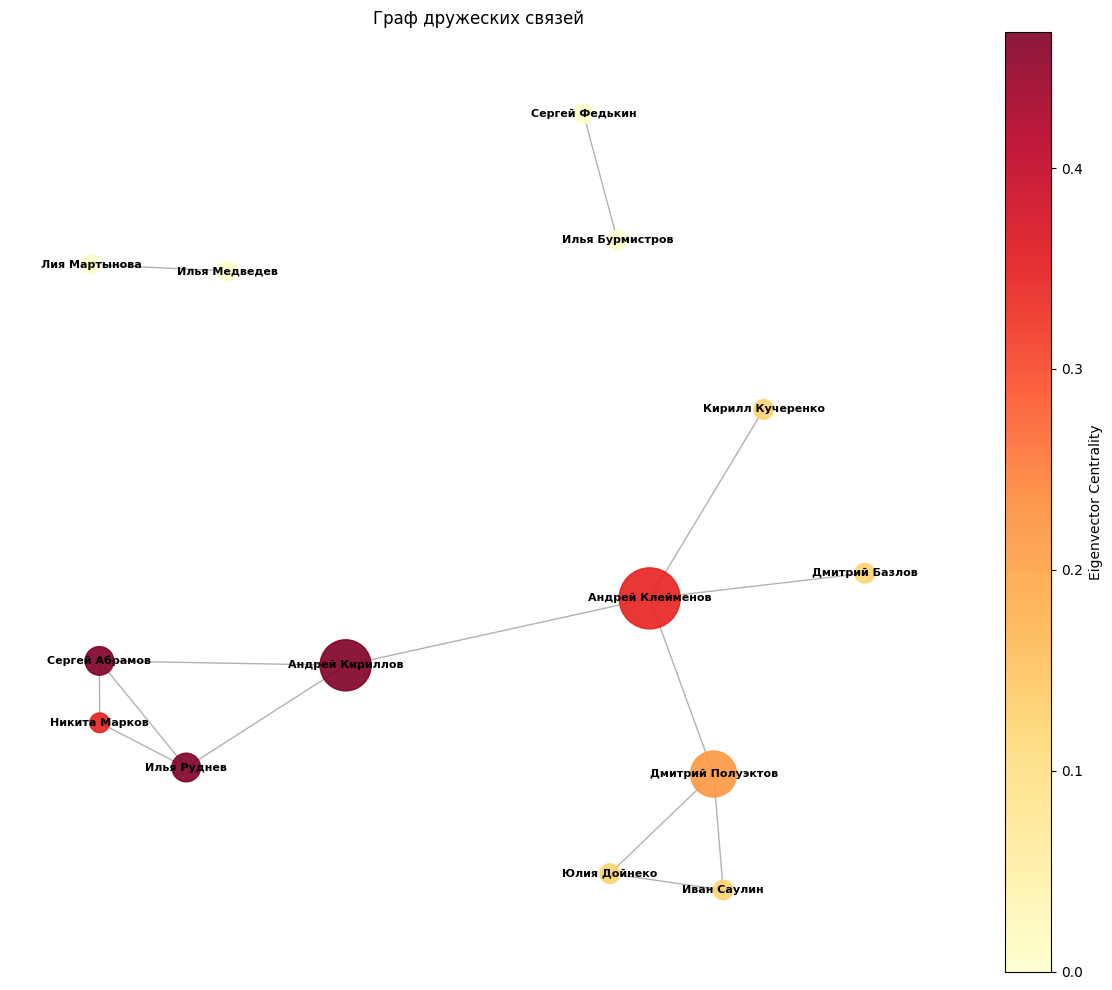

In [225]:
import matplotlib.pyplot as plt

# Настраиваем размер картинки
plt.figure(figsize=(12, 10))

# Позиции узлов (алгоритм «пружины»)
pos = nx.spring_layout(G, seed=42, k=0.6)

# Размер узлов зависит от Betweenness (чем больше, тем крупнее)
node_sizes = [betweenness[n] * 5000 + 200 for n in G.nodes()]

# Цвет узлов зависит от Eigenvector (чем больше, тем краснее)
node_colors = [eigenvector[n] for n in G.nodes()]

# Рисуем узлы
nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.YlOrRd,
    alpha=0.9
)

# Рисуем рёбра
nx.draw_networkx_edges(G, pos, alpha=0.3, width=1)

# Подписи узлов — имена (если есть), иначе ID
labels = {n: id_to_name.get(n, str(n)) for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold')

plt.colorbar(nodes, label='Eigenvector Centrality')

plt.title("Граф дружеских связей")
plt.axis('off')
plt.tight_layout()

plt.savefig('graph.png', dpi=300, bbox_inches='tight')
print("Картинка сохранена")

plt.show()

In [217]:
print("Вывод:")
print("\nТоп-3 по посредничеству (Betweenness)")
top_betweenness = results.nlargest(3, 'Betweenness')[['ID', 'Имя', 'Betweenness']]
print(top_betweenness.to_string(index=False))

print("\nТоп-3 по близости (Closeness)")
top_closeness = results.nlargest(3, 'Closeness')[['ID', 'Имя', 'Closeness']]
print(top_closeness.to_string(index=False))

print("\nТоп-3 по собственному вектору (Eigenvector)")
top_eigenvector = results.nlargest(3, 'Eigenvector')[['ID', 'Имя', 'Eigenvector']]
print(top_eigenvector.to_string(index=False))

Вывод:

Топ-3 по посредничеству (Betweenness)
       ID               Имя  Betweenness
422397933  Андрей Клейменов       0.3462
357111839   Андрей Кириллов       0.2308
299547783 Дмитрий Полуэктов       0.1795

Топ-3 по близости (Closeness)
       ID               Имя  Closeness
422397933  Андрей Клейменов     0.4154
357111839   Андрей Кириллов     0.3665
299547783 Дмитрий Полуэктов     0.3279

Топ-3 по собственному вектору (Eigenvector)
       ID             Имя  Eigenvector
357111839 Андрей Кириллов       0.4676
354792455  Сергей Абрамов       0.4675
278508214     Илья Руднев       0.4675
